# Exploratory Data Analysis — Telco Customer Churn

This notebook explores the Telco Customer Churn dataset *before* modeling, to understand:

1. **Data quality** — types, missing values, oddities to clean.
2. **Target balance** — how many customers actually churn.
3. **Drivers of churn** — which customer attributes relate to leaving.

The findings here motivate the preprocessing and modeling choices made in the pipeline
(`churn/components/`). Dataset: IBM Telco Customer Churn — ~7,043 customers, 21 columns,
binary target `Churn` (Yes/No).

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# path is relative to the notebooks/ folder
DATA_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)

print("Rows, columns:", df.shape)
df.head()

Rows, columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Structure and data types

Note that `TotalCharges` comes in as an `object` (text) rather than a number — a hint that
some values aren't clean numerics. We'll confirm why in the next section.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 3. Data quality

In [4]:
# TotalCharges is stored as text because a few rows are blank (" ")
blank_total = (df["TotalCharges"] == " ").sum()
print("Blank TotalCharges values:", blank_total)

# coerce to numeric — blanks become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows that became NaN:", df["TotalCharges"].isna().sum())
print("Their tenure values:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())

print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate rows:", df.duplicated().sum())

Blank TotalCharges values: 11
Rows that became NaN: 11
Their tenure values: [0]

Missing values per column:
TotalCharges    11
dtype: int64

Duplicate rows: 0


**Finding:** the 11 blank `TotalCharges` rows all have `tenure = 0` — brand-new customers
who haven't completed a billing cycle yet. There are no duplicate rows and no other missing
values. This is exactly the check the pipeline's `data_validation` stage enforces, and the
`data_transformation` stage coerces this column to numeric.

## 4. Target balance — how many customers churn?

Churn
No     0.7346
Yes    0.2654
Name: proportion, dtype: float64


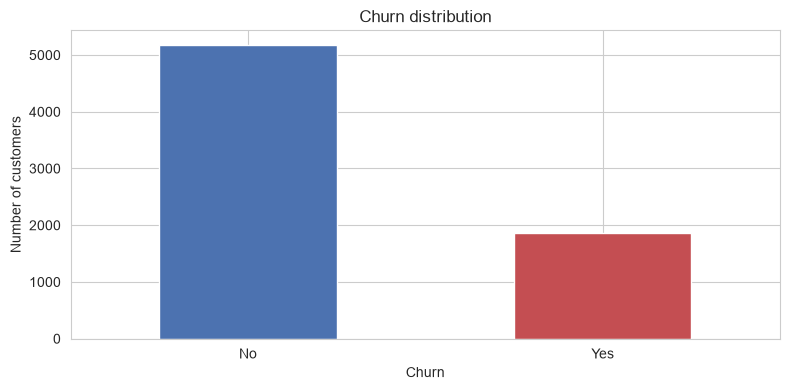

In [5]:
churn_rate = df["Churn"].value_counts(normalize=True)
print(churn_rate.round(4))

ax = df["Churn"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"])
ax.set_title("Churn distribution")
ax.set_xlabel("Churn"); ax.set_ylabel("Number of customers")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Finding:** about **26.5%** of customers churn — the classes are imbalanced. This is why the
modeling step uses class weighting (`class_weight="balanced"` / `scale_pos_weight`) and is
evaluated on ROC-AUC and recall rather than plain accuracy (a model that always predicts
"No" would score 73% accuracy while catching zero churners).

## 5. Numeric drivers — tenure and charges

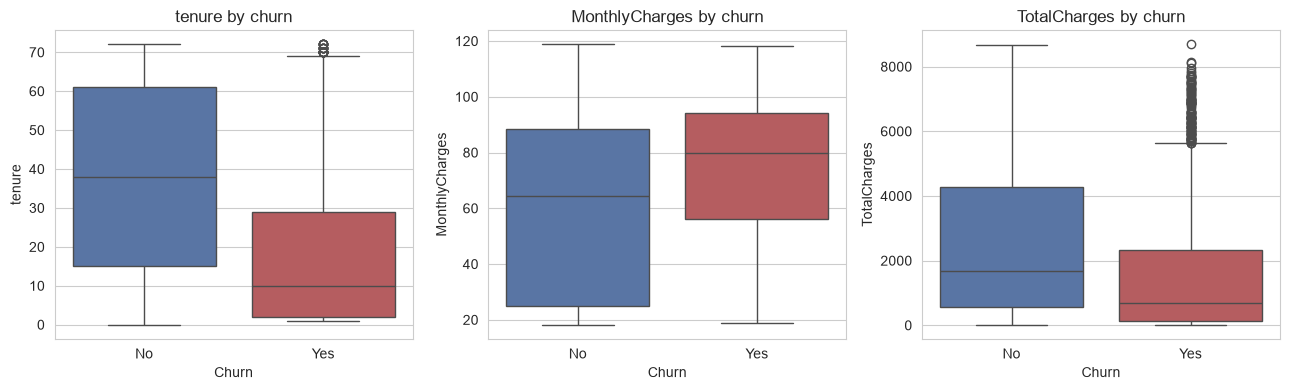

       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       37.6            61.3        2555.3
Yes      18.0            74.4        1531.8


In [6]:
df = df.drop(columns=["customerID"])
df["churn_bin"] = (df["Churn"] == "Yes").astype(int)

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x="Churn", y=col, hue="Churn", legend=False,
                palette=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(f"{col} by churn")
plt.tight_layout(); plt.show()

print(df.groupby("Churn")[num_cols].mean().round(1))

**Finding:** churned customers have far **lower tenure** (≈18 vs 38 months on average) and
**higher monthly charges** (≈74 vs 61). In plain terms: customers who leave tend to be newer
and on pricier plans.

## 6. Categorical drivers — contract, internet, payment, age

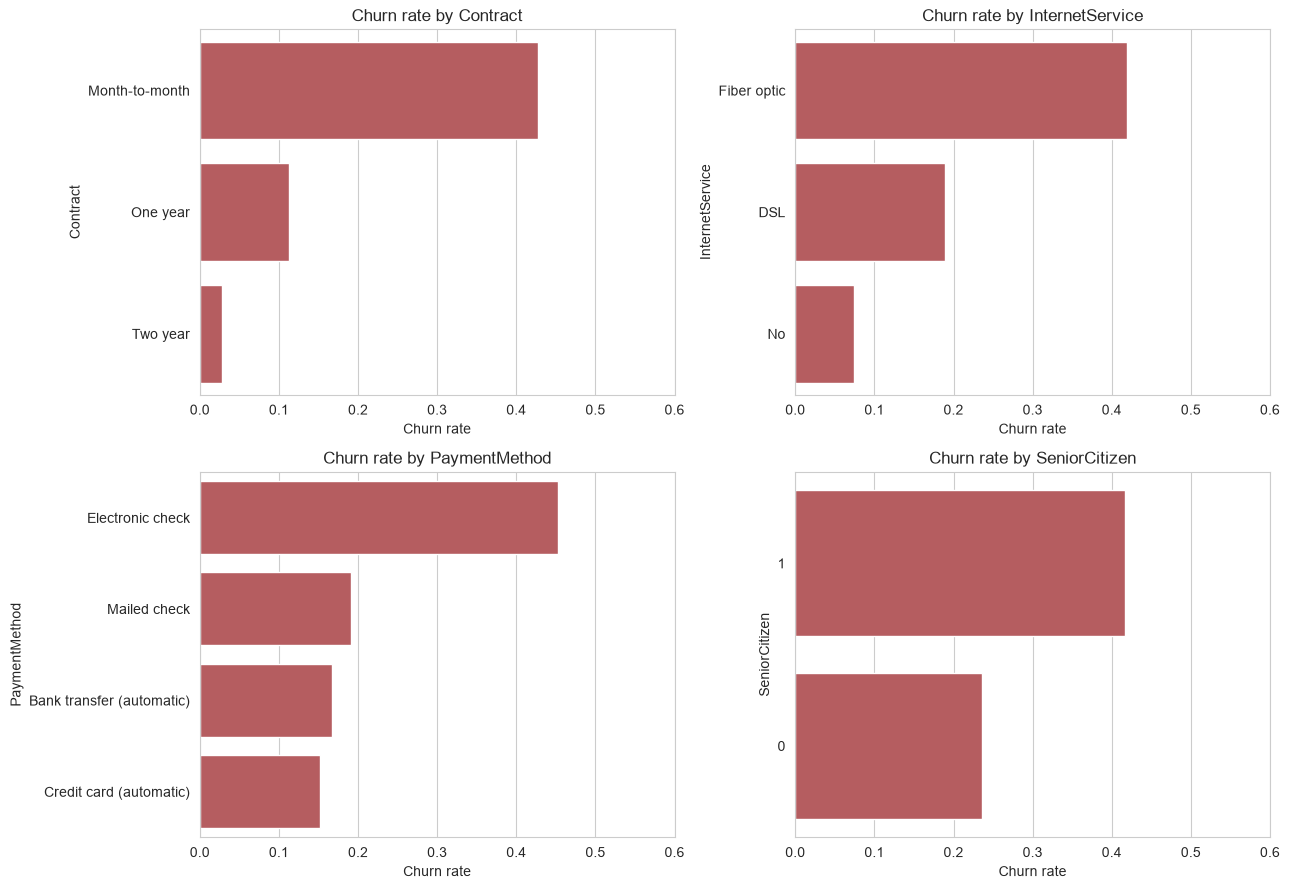

In [7]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "SeniorCitizen"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols):
    rates = df.groupby(col)["churn_bin"].mean().sort_values(ascending=False)
    sns.barplot(x=rates.values, y=rates.index.astype(str), color="#C44E52", ax=ax)
    ax.set_title(f"Churn rate by {col}")
    ax.set_xlabel("Churn rate"); ax.set_xlim(0, 0.6)
plt.tight_layout(); plt.show()

**Finding:** the strongest categorical signal is **contract type** — month-to-month customers
churn ~43%, versus ~11% (one year) and ~3% (two year). **Fiber-optic** internet (~42%),
**electronic-check** payment (~45%), and **senior citizens** (~42%) also churn well above
average. These are the features the model leans on most.

## 7. Correlation of numeric features with churn

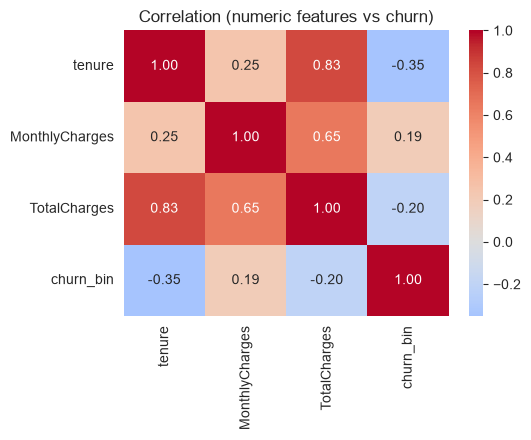

In [8]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "churn_bin"]].corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation (numeric features vs churn)")
plt.tight_layout(); plt.show()

**Finding:** `tenure` has the strongest (negative) correlation with churn (≈ -0.35) — the
longer someone has been a customer, the less likely they are to leave. `MonthlyCharges`
is mildly positive (≈ +0.19).

## 8. Summary of findings

- **Imbalanced target** (~26.5% churn) → handle with class weighting; evaluate on ROC-AUC /
  recall, not accuracy.
- **Tenure is the strongest driver** — newer customers churn far more.
- **Contract type matters most among categoricals** — month-to-month customers churn ~15×
  more than two-year customers.
- **Fiber optic, electronic check, senior citizens, and higher monthly charges** all associate
  with higher churn.
- **Data quality** — 11 blank `TotalCharges` values (all tenure-0 new customers) need handling;
  no duplicates, no other missing data.

These observations directly justify the pipeline's choices: drop `customerID`, coerce
`TotalCharges` to numeric, encode and scale features, split with stratification to preserve the
churn ratio, and train class-weighted models selected on ROC-AUC.